<a href="https://colab.research.google.com/github/api-sage/diaml_projects/blob/main/Project1/pafolabi_DIAML_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
# Imports ALL neccessary libraries
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
import datetime as datetime
import seaborn as sns

In [71]:
# Function that helps compute the fold count needed to exceed Mt. Everest
# given paper thickness in mm
def exceed_mount_everest(paper_thickness_in_mm: float) -> float:
  height_of_mount_everest_in_meters = 8848
  paper_thickness_in_meters = paper_thickness_in_mm / 1000
  calculated_thickness_height = 0
  calculated_fold_count = 1
  while(calculated_thickness_height < height_of_mount_everest_in_meters):
    calculated_thickness_height = 2**calculated_fold_count * paper_thickness_in_meters
    if calculated_thickness_height > height_of_mount_everest_in_meters:
      break
    calculated_fold_count += 1

  return calculated_fold_count

In [72]:
paper_thickness_in_mm = 0.1
tissue_paper_thickness_in_mm = 0.05
card_stock_thickness_in_mm = 0.3
# ANS: Q1(a) ==> How many folds does it take to exceed the height of Mount Everest at 8,848 m?
print(exceed_mount_everest(paper_thickness_in_mm))
print(exceed_mount_everest(tissue_paper_thickness_in_mm))
print(exceed_mount_everest(card_stock_thickness_in_mm))

27
28
25


ANS Q1(b): Observation on how my answer changes across different paper types


1.   It is observed that as paper thickness reduces, the number of folds increases. Hence, the thickness, t, of a paper is inversely proportinal to the number of folds required to exceed mount everest.


In [73]:
# Q1(c) ==> Function that helps get initial thickness given number of folds
def get_initial_thickness(no_of_folds: int) -> float:
  height_of_mount_everest_in_meters = 8848
  # using the formula of initial_thickness_in_meters * 2**no_of_folds = height_of_mount_everest_in_meters
  # initial_thickness_in_meters = height_of_mount_everest_in_meters / 2**no_of_folds
  initial_thickness_in_meters = height_of_mount_everest_in_meters / 2**no_of_folds
  return initial_thickness_in_meters * 1000

In [74]:
# ANS: Q1(c) ==> At what initial thickness would exactly 20 folds be enough?
print(get_initial_thickness(20))
# Proof to Q1(c) ANS: To verify that get_initial_thickness works, the below method was tested using the output of the get_initial_thickness method
print(exceed_mount_everest(8.438))


8.4381103515625
21


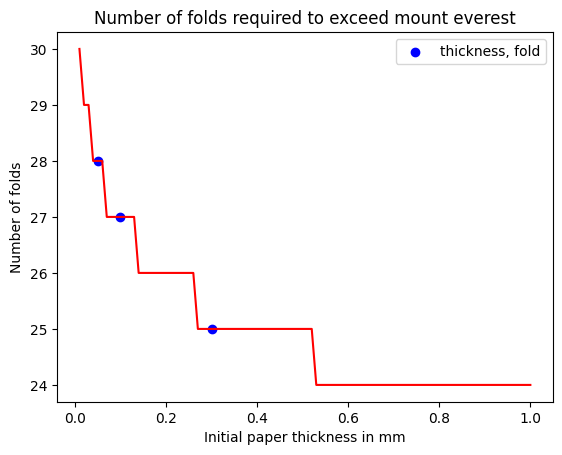

In [75]:
# ANS: Q1(d) ==> Plot the number of folds required as a function of paper thickness, mark all 3
# thickness and their folds, and explain what the shape of that curve tells you
thickness_range = np.linspace(0.01, 1, 100)
thickness_fold = np.vectorize(exceed_mount_everest)(thickness_range)
plt.plot(thickness_range, thickness_fold, color='red')
map_thicknesses = [tissue_paper_thickness_in_mm, paper_thickness_in_mm, card_stock_thickness_in_mm]
map_folds = [exceed_mount_everest(map_thicknesses[0]),exceed_mount_everest(map_thicknesses[1]),exceed_mount_everest(map_thicknesses[2])]
plt.scatter(map_thicknesses, map_folds, color='blue', label='thickness, fold')
plt.ylabel('Number of folds')
plt.xlabel('Initial paper thickness in mm')
plt.title('Number of folds required to exceed mount everest')
plt.legend()

In [76]:
def t_to_drop_below_x_percent(percentage_threshold: float, a: float) -> float:
  # Using the formular v(t)=v(0)exp(-at)
  # Where:
  #   v(t) is the volume of water as a function of time t
  #   v(0) is the initial volume of water at t = 0
  #   a is the decay constant
  #   t is the time in days
  # Going by the formular, to find the amount of time t for the initial
  # volume of water to fall below a percentage threshold, t becomes

  t = math.log(percentage_threshold/100) / -a
  return t


In [77]:
print(t_to_drop_below_x_percent(50,0.05))
print(t_to_drop_below_x_percent(10,0.05))
print(t_to_drop_below_x_percent(9,0.05))
print(t_to_drop_below_x_percent(50,0.15))
print(t_to_drop_below_x_percent(10,0.15))
print(t_to_drop_below_x_percent(9,0.15))

13.862943611198904
46.05170185988091
48.15891217303744
4.620981203732969
15.350567286626971
16.052970724345816


Assuming that the reservoir has a uniform cross-section and the discharge valve that
gets water out of the tank is positioned at 10% of the height of the reservoir,
one can deduce that at 10% of the initial volume, the discharge pressure has
reduced significantly that only droplets of water would come out.
However, just slightly below the 10% (9%) of the height where the discharge valve
is positioned, the reservior becomes effectively unable to discharge water.
Hence, the reservoir becomes effectively empty at 9% of the initial volume.
It will take 48.15 days for the reservoir to attain that volume depreciation.

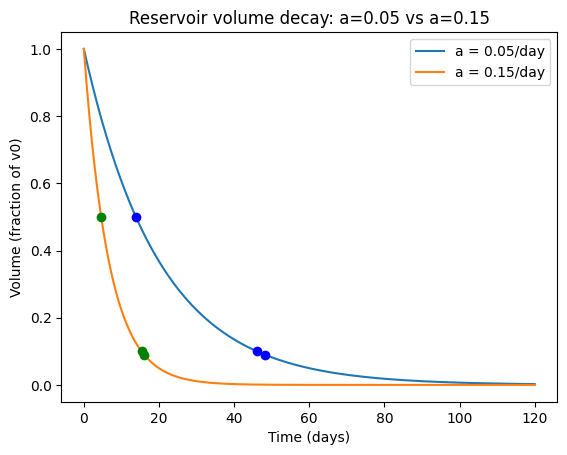

In [78]:
# The actual decay curves, evaluated over a range of time
t_range = np.linspace(0, 120, 500)
v0 = 1

v_a05 = v0 * np.exp(-0.05 * t_range)
v_a15 = v0 * np.exp(-0.15 * t_range)

plt.plot(t_range, v_a05, label='a = 0.05/day')
plt.plot(t_range, v_a15, label='a = 0.15/day')

# Mark the threshold points on the curves
t_thresholds_a05 = [t_to_drop_below_x_percent(50, 0.05), t_to_drop_below_x_percent(10, 0.05), t_to_drop_below_x_percent(9, 0.05)]
v_thresholds = [0.5, 0.10, 0.09]  # the corresponding volume fractions

plt.scatter(t_thresholds_a05, v_thresholds, color='blue', zorder=5)

t_thresholds_a15 = [t_to_drop_below_x_percent(50, 0.15), t_to_drop_below_x_percent(10, 0.15), t_to_drop_below_x_percent(9, 0.15)]
plt.scatter(t_thresholds_a15, v_thresholds, color='green', zorder=5)

plt.xlabel('Time (days)')
plt.ylabel('Volume (fraction of v0)')
plt.title('Reservoir volume decay: a=0.05 vs a=0.15')
plt.legend()
plt.show()

In [79]:
# Computes compound interests and balance given P, R and T
def compute_compound_interest(principal: float, interest_rate_in_percentage: float, time_in_years: int) -> float:
  return principal * (1 + interest_rate_in_percentage/100)**time_in_years

In [80]:
# ANS: Q3(a) ==> Calculate the balance after 1, 2, 3, 4, and 5 years. Show your working
print(compute_compound_interest(500, 5, 1))
print(compute_compound_interest(500, 5, 2))
print(compute_compound_interest(500, 5, 3))
print(compute_compound_interest(500, 5, 4))
print(compute_compound_interest(500, 5, 5))

525.0
551.25
578.8125000000001
607.7531250000001
638.1407812500001


In [81]:
# Given the current savings rate of two banks operating in Rwanda::
# 1. I&M Bank: 9.5% per annum - https://www.imbankgroup.com/rw/personal/bank-accounts/savings/
# 2. GT Bank: 4% per annum - https://www.gtbank.co.rw/personal-banking/accounts/savings-investment-accounts/savings-account

# For I&M Bank
print(compute_compound_interest(500, 9.5, 1))
print(compute_compound_interest(500, 9.5, 2))
print(compute_compound_interest(500, 9.5, 3))
print(compute_compound_interest(500, 9.5, 4))
print(compute_compound_interest(500, 9.5, 5))

547.5
599.5125
656.4661874999999
718.8304753124999
787.1193704671874


In [82]:
# For GT Bank
print(compute_compound_interest(500, 4, 1))
print(compute_compound_interest(500, 4, 2))
print(compute_compound_interest(500, 4, 3))
print(compute_compound_interest(500, 4, 4))
print(compute_compound_interest(500, 4, 5))

520.0
540.8000000000001
562.432
584.9292800000001
608.3264512000001


In [83]:
# At what deposit amount would the difference between the 5% rate
# and your best local bank rate exceed $100?
def compute_deposit_amount_to_exceed_threshold(threshold_difference_in_usd: float, principal: float, time_years: int) -> float:
  while compute_compound_interest(principal, 9.5, time_years) - compute_compound_interest(principal, 5, time_years) < threshold_difference_in_usd:
    principal += 1
  return principal

In [84]:
print(compute_deposit_amount_to_exceed_threshold(100, 500, 5))

500


In [85]:
# Q4: Computes monthly payments
def compute_monthly_payments(principal: float, monthly_interest_rate_in_percentage: float, time_in_years: int) -> float:
    r = monthly_interest_rate_in_percentage / 100
    n = time_in_years * 12
    return principal * (r * (1 + r)**n) / ((1 + r)**n - 1)

In [86]:
# ANS: Q4(a) ==> Calculate the monthly payment required to clear the debt in 1, 2, and 3 years.
# Round to the nearest dollar.
car_monthly_payment_yr1 = np.round(compute_monthly_payments(20000, 5, 1))
car_monthly_payment_yr2 = np.round(compute_monthly_payments(20000, 5, 2))
car_monthly_payment_yr3 = np.round(compute_monthly_payments(20000, 5, 3))
print(car_monthly_payment_yr1)
print(car_monthly_payment_yr2)
print(car_monthly_payment_yr3)

2257.0
1449.0
1209.0


In [87]:
# Q4(b) ==> with effective car price reducing by 15% of $20k for electric cars
electric_car_price = 20000 - (20000 * 0.15)
print(electric_car_price)
'''
Q4(b) ==> Recalculate the monthly payment for one, two, and
three years under this new price. How much will you save if you pay in one, two,
and three years compared to the original loan?
'''
electric_car_monthly_payment_yr1 = np.round(compute_monthly_payments(electric_car_price, 5, 1))
electric_car_monthly_payment_yr2 = np.round(compute_monthly_payments(electric_car_price, 5, 2))
electric_car_monthly_payment_yr3 = np.round(compute_monthly_payments(electric_car_price, 5, 3))
print("Monthly payment for electric car 1year::", electric_car_monthly_payment_yr1)
print("Monthly payment for electric car 2year::", electric_car_monthly_payment_yr2)
print("Monthly payment for electric car 3year::", electric_car_monthly_payment_yr3)

'''
Comparing these values with the original values if a non-electric car was purchased,
below are the respective amounts that will be saved per year
'''
payment_diff_original_electric_yr1 = car_monthly_payment_yr1 - electric_car_monthly_payment_yr1
payment_diff_original_electric_yr2 = car_monthly_payment_yr2 - electric_car_monthly_payment_yr2
payment_diff_original_electric_yr3 = car_monthly_payment_yr3 - electric_car_monthly_payment_yr3

print("Amount to be saved per month of year 1::", payment_diff_original_electric_yr1)
print("Amount to be saved per month of year 2::", payment_diff_original_electric_yr2)
print("Amount to be saved per month of year 3::", payment_diff_original_electric_yr3)

# Total amount to be saved per year
total_saved_1yr = payment_diff_original_electric_yr1 * 12
total_saved_2yr = payment_diff_original_electric_yr2 * 24
total_saved_3yr = payment_diff_original_electric_yr3 * 36

print(total_saved_1yr)
print(total_saved_2yr)
print(total_saved_3yr)

# Total amount that would have been saved by the end of the payment (yr1+yr2+yr3)
print("Total amount saved::", total_saved_1yr + total_saved_2yr + total_saved_3yr)

17000.0
Monthly payment for electric car 1year:: 1918.0
Monthly payment for electric car 2year:: 1232.0
Monthly payment for electric car 3year:: 1027.0
Amount to be saved per month of year 1:: 339.0
Amount to be saved per month of year 2:: 217.0
Amount to be saved per month of year 3:: 182.0
4068.0
5208.0
6552.0
Total amount saved:: 15828.0


In [88]:
# Q5 ==> Investment and Repayment Duration
def computes_cumulative_profit(principal: float, initial_no_of_customers: int, percent_rate_of_customer_growth: float, daily_profit_per_customer: float) -> dict[int, float]:
  days_count = 1
  cumulative_profits_per_day = {}
  total_cumulative_profit = 0
  customer_count = initial_no_of_customers
  todays_profit = customer_count * daily_profit_per_customer
  cumulative_profits_per_day[days_count] = todays_profit
  total_cumulative_profit += todays_profit
  while(total_cumulative_profit < principal):
    days_count += 1
    customer_count = customer_count + (customer_count * percent_rate_of_customer_growth/100)
    todays_profit = customer_count * daily_profit_per_customer
    cumulative_profits_per_day[days_count] = cumulative_profits_per_day[days_count-1] + todays_profit
    total_cumulative_profit += todays_profit

  return cumulative_profits_per_day

In [89]:
initial_investment_amount = 100000
cumulative_profit_per_day = computes_cumulative_profit(initial_investment_amount, 40, 0.5, 5)
total_days_to_repay = len(cumulative_profit_per_day)
# ANS: Q5(a) ==> It will take Two hundred and fifty-two days(252) days to repay the initial investment of $100,000
print(total_days_to_repay)

252


Text(0.5, 1.0, 'A graph showing cumulative profit per day of an initial investment')

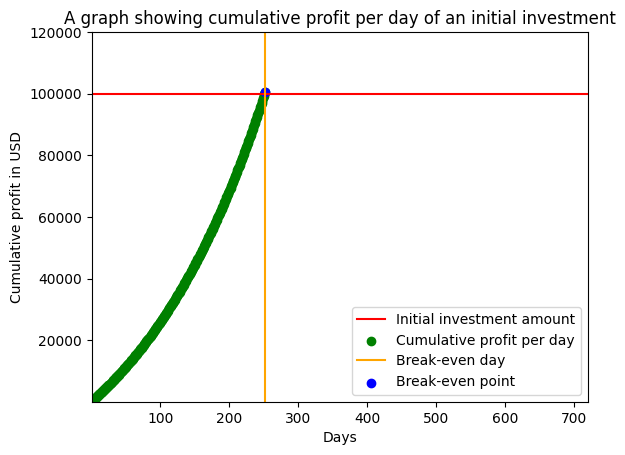

In [90]:
x_axis_values = plt.xlim(1,720)
y_axis_values = plt.ylim(1,120000)
plt.plot(x_axis_values, y_axis_values, color='none')
plt.axhline(initial_investment_amount, color = 'red', label = 'Initial investment amount')
plot_cumulative_profit_per_day = list(cumulative_profit_per_day.values())
plot_days = list(cumulative_profit_per_day.keys())
plt.scatter(plot_days, plot_cumulative_profit_per_day, color='green', label='Cumulative profit per day')
plt.axvline(total_days_to_repay, color = 'orange', label = 'Break-even day')
plt.scatter(total_days_to_repay, cumulative_profit_per_day[total_days_to_repay], color='blue', label='Break-even point')
plt.legend()
plt.xlabel('Days')
plt.ylabel('Cumulative profit in USD')
plt.title('A graph showing cumulative profit per day of an initial investment')

In [91]:
'''
Q5(c) ==> Bank of Kigali offers to double your initial investment to $200,000 in exchange
for a 50% share of daily profits. As an entrepreneur, would you take the deal if
the customers grow at 0.7% due to the deal?
'''
bok_initial_investment_amount = 200000
bok_cumulative_profit_per_day = computes_cumulative_profit(bok_initial_investment_amount, 40, 0.7, 5)
bok_total_days_to_repay = len(bok_cumulative_profit_per_day)
# Days to breakeven
print("Days to break-even with BoK partnership::", bok_total_days_to_repay)
print("Break-even amount and profit to business without BoK", np.round(cumulative_profit_per_day[total_days_to_repay]))
print("Break-even Amount with BoK::", np.round(bok_cumulative_profit_per_day[bok_total_days_to_repay]))
print("Profit to business after sharing ratio of 50% with BoK::",
      np.round(bok_cumulative_profit_per_day[bok_total_days_to_repay] * 0.5))
print("Difference in profit with BoK and profit without BoK::", np.round(bok_cumulative_profit_per_day[bok_total_days_to_repay] * 0.5) - np.round(cumulative_profit_per_day[total_days_to_repay]))

Days to break-even with BoK partnership:: 299
Break-even amount and profit to business without BoK 100575.0
Break-even Amount with BoK:: 201437.0
Profit to business after sharing ratio of 50% with BoK:: 100718.0
Difference in profit with BoK and profit without BoK:: 143.0


**Q5(c) Explanation**::
According to the results, if the Bank of Kigali chooses to double my investment (meaning that they are investing $100,000 to make my total investment USD200,000) for a 50% daily profit share at a daily customer growth rate of 0.7%, it would take 299 days to break-even. Without the partnership, I will make USD100,575 at the 252nd day. With the partnership, I will make a total of USD201,437 by the 299th day, and after sharing 50% with BoK, it becomes USD100,718. Comparing USD100,718 to USD100,575, I have waited for 47 extra days just to earn ~USD143 more than what I would have earned without the partnership. The partnership at those rates are not good for business. Agreeing to the partnership at those values also means that I am purchasing just 0.2% daily customer growth for more money than I will be making. The partnership makes customer aquisition more expensive and reduces average daily profit per customer. Not worth it. I will not take the offer.

**Q6 ==> Progression Analysis of Ebola outbreak in DRC using 2026 DRC Ebola Surveillance Dataset**

In [92]:
drc_dataset = "https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project1/drc_zones_timeseries-zonal%20(1).csv"
df = pd.read_csv(drc_dataset)
# Dataset exporation and cleaning
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df.Date = pd.to_datetime(df.Date)
df.Province = df.Province.astype('string')
df.Province = df.Province.replace({'Haut-UÃ©lÃ©': 'Haut-Uélé', 'Haut-Uele': 'Haut-Uélé'})
df['Health Zone'] = df['Health Zone'].astype('string')
df.info() # This reconfirms post-cleaning df info

# This function analyses the cleaned dataset which has been moved into the dataframe
def analyse_ebola_progression(cleaned_data: pd.DataFrame) -> dict[str, object]:
  affected_provinces = list(cleaned_data.Province.unique())
  no_of_provinces_affected = int(len(affected_provinces))
  no_of_cases = int(cleaned_data['Confirmed Cases'].sum())
  no_of_deaths = int(cleaned_data['Confirmed Deaths'].sum())
  data_by_province = {}
  national_dailies_report = {}

  # This iterate over each group, where 'date_key' is the date and 'date_data' is the data for that date
  for date_key, date_data in cleaned_data.groupby('Date'):
    daily_province_summary = {} # Initialize for each date
    for province in affected_provinces:
      province_data_for_day = date_data[date_data['Province'] == province]
      confirmed_cases_for_day = province_data_for_day['Confirmed Cases'].sum()
      confirmed_deaths_for_day = province_data_for_day['Confirmed Deaths'].sum()
      daily_province_summary[province] = {
          'confirmed_cases': int(confirmed_cases_for_day),
          'confirmed_deaths': int(confirmed_deaths_for_day)
      }
    summary = {'total_confirmed_cases': sum(x['confirmed_cases'] for x in daily_province_summary.values()),
               'total_confirmed_deaths': sum(x['confirmed_deaths'] for x in daily_province_summary.values())}
    daily_province_summary['summary'] = summary
    national_dailies_report[date_key] = daily_province_summary

  national_dailies_report = dict(sorted(national_dailies_report.items(),
                                            key = lambda item: item[0]))

  for province in affected_provinces:
    confirmed_cases_by_province = int(cleaned_data['Confirmed Cases'].where(cleaned_data.Province == province).sum())
    confirmed_deaths_by_province = int(cleaned_data['Confirmed Deaths'].where(cleaned_data.Province == province).sum())
    data_by_province[province] = {'confirmed_cases':confirmed_cases_by_province, 'confirmed_deaths': confirmed_deaths_by_province}

  return {"affected_provinces":affected_provinces,
          "no_of_provinces_affected": no_of_provinces_affected,
          "total_no_of_confirmed_cases": no_of_cases,
          "total_no_of_confirmed_deaths": no_of_deaths,
          "detailed_report_by_province": data_by_province,
          "national_dailies_report": national_dailies_report}

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2349 entries, 0 to 2348
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              2349 non-null   object 
 1   Health Zone       2349 non-null   object 
 2   Province          2349 non-null   object 
 3   Confirmed Cases   2349 non-null   int64  
 4   Confirmed Deaths  2265 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 91.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2349 entries, 0 to 2348
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              2349 non-null   datetime64[ns]
 1   Health Zone       2349 non-null   string        
 2   Province          2349 non-null   string        
 3   Confirmed Cases   2349 non-null   int64         
 4   Confirmed Deaths  2265 non-null   float64       
dtypes: datetime64

In [93]:
# Q6(a)
drc_ebola_progression_analyses = analyse_ebola_progression(df)
print(drc_ebola_progression_analyses)

{'affected_provinces': ['Ituri', 'Nord-Kivu', 'Sud-Kivu', 'Tshopo', 'Haut-Uélé'], 'no_of_provinces_affected': 5, 'total_no_of_confirmed_cases': 99077, 'total_no_of_confirmed_deaths': 36777, 'detailed_report_by_province': {'Ituri': {'confirmed_cases': 88727, 'confirmed_deaths': 30553}, 'Nord-Kivu': {'confirmed_cases': 9350, 'confirmed_deaths': 5675}, 'Sud-Kivu': {'confirmed_cases': 180, 'confirmed_deaths': 58}, 'Tshopo': {'confirmed_cases': 117, 'confirmed_deaths': 87}, 'Haut-Uélé': {'confirmed_cases': 703, 'confirmed_deaths': 404}}, 'national_dailies_report': {Timestamp('2026-05-14 00:00:00'): {'Ituri': {'confirmed_cases': 0, 'confirmed_deaths': 0}, 'Nord-Kivu': {'confirmed_cases': 0, 'confirmed_deaths': 0}, 'Sud-Kivu': {'confirmed_cases': 0, 'confirmed_deaths': 0}, 'Tshopo': {'confirmed_cases': 0, 'confirmed_deaths': 0}, 'Haut-Uélé': {'confirmed_cases': 0, 'confirmed_deaths': 0}, 'summary': {'total_confirmed_cases': 0, 'total_confirmed_deaths': 0}}, Timestamp('2026-05-15 00:00:00'): {

### Q6(b): Data Quality - Missing Dates and Inconsistencies

According to the WHO situation [report](https://www.who.int/emergencies/alert-and-response) (Screenshot on Fig. 1) on the outbreak of Ebola virus in DRC as at
27th August 2026, there are 5,863 confirmed cases with 2,824 confirmed deaths. These values are significantly lower when compared to 99,077 total number of confirmed cases and 36,777 total number of confirmed deaths derived from the dataset used for this progression analysis.

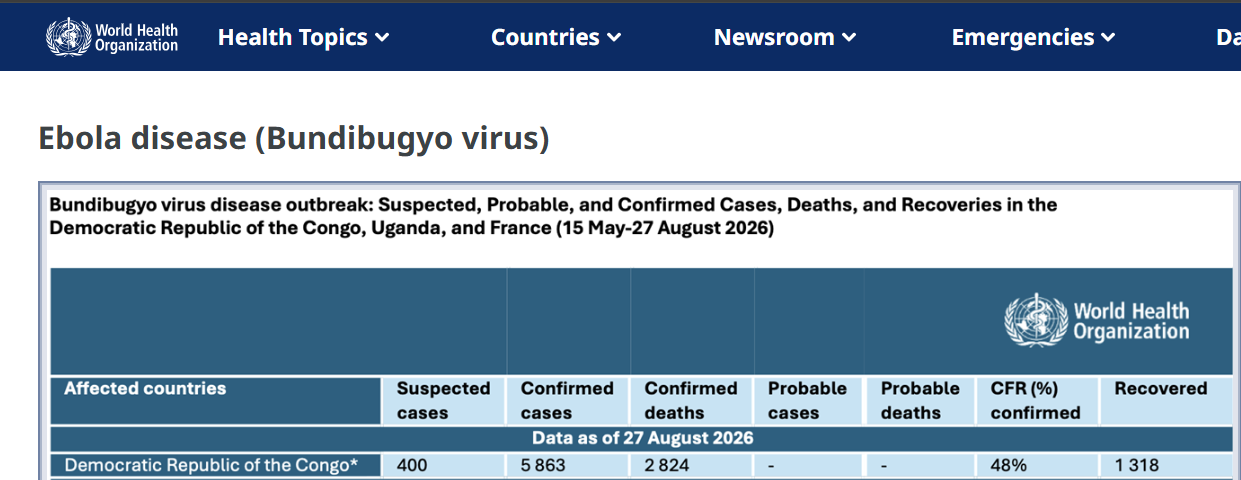

                                                                Fig. 1

In [94]:
reports_by_dates = drc_ebola_progression_analyses['national_dailies_report']
data_rows = []
for date, data in reports_by_dates.items():
    data_rows.append({
        'Date': date,
        'total_confirmed_cases': data['summary']['total_confirmed_cases'],
        'total_confirmed_deaths': data['summary']['total_confirmed_deaths']
    })

national_daily_df = pd.DataFrame(data_rows)
national_daily_df['Date'] = pd.to_datetime(national_daily_df.Date)
min_date = national_daily_df.Date.min()
max_date = national_daily_df.Date.max()
full_date_range = pd.DataFrame({'Date': pd.date_range(start=min_date, end=max_date, freq='D')})
mis = pd.merge(full_date_range, national_daily_df, on='Date', how='left')
missing_dates_df = mis[mis['total_confirmed_cases'].isnull() | mis['total_confirmed_deaths'].isnull()]

print(f"Dataset Date Range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Number of missing dates: {len(missing_dates_df)}")
# Missing dates
display(missing_dates_df)

Dataset Date Range: 2026-05-14 to 2026-08-04
Number of missing dates: 11


,Date,total_confirmed_cases,total_confirmed_deaths
2,2026-05-16,NaN,NaN
3,2026-05-17,NaN,NaN
17,2026-05-31,NaN,NaN
29,2026-06-12,NaN,NaN
43,2026-06-26,NaN,NaN
44,2026-06-27,NaN,NaN
45,2026-06-28,NaN,NaN
59,2026-07-12,NaN,NaN
63,2026-07-16,NaN,NaN
75,2026-07-28,NaN,NaN


 **Analysis of Missing Dates**

According to my analyses, 11 dates are missing from the dataset. This raises a few questions in my mind:
1. Was it that there were no instances of confirmed cases or confirmed deaths on these dates?
2. If the answer is a NO, could it be a human error where someone who took the readings forgot to report them officially?
3. Could it be a logistical challenge that led to the loss of these data on observed dates?
While finding answers to these questions are beyond my scope of work as a data analyst and scientist on this project, the missing dates pattern revealed by the missing dates vis-a-vis the dates in the available dataset suggests random data loss. Below are my observations that led to that conclusion:
1. Not all missing dates fell on a weekend. One could have assumed that data was not gathered and reported on weekends, but some weekend dates in the same month and in other months have reports. Case in point 2026-05-16, 17, 31 and 2025-05-30. Hence the missing dates do not suggest a structured reporting pattern, rather, a random one.
2. Some missing date fell on a workday that is not an official holiday date in DRC. One could have as well assumed that probably there were official holidays on certain dates and maybe essential services chose not to work (which is very strange across the world by the way), but some missing dates are workdays. Case in point is 2026-07-16. Hence, this suggests that the missing dates pattern is a random one.

To address this issue of missing dates, interpolation strategies are crucial, as explored in part (c).

**Q6(c): Data Interpolation Methods and Analysis**

When dealing with missing values in a time series, several interpolation methods can be employed, each with its own assumptions and implications:

1.  **Linear Interpolation**: This assumes that the rate of change between data points are constant, hence it estimates missing values by drwaing a straight line between known values to the missing one. While this is the simplest and computationally cheapest interpolation methodology, it yields a curve with sharp edges; which does not reflect real-world smooth transition scenarios.
2.  **Step Interpolation or Forward-fill (Nearest interpolation)**: This interpolation technique assumes that no change has occured since the last data point. Hence, it uses the value(s) of the last data point to fill the missing values until the next known data point. This technique is useful when dealing with time series systems and event driven architectures.
3.  **Cubic Spline Interpolation**: This interpolation technique uses a third degree polynomial to draw connection between data points. It forces the first and second derivatives of the data points to match at the edges, yielding a smooth curve that reflect real world transition. This is often used in systems where sharp changes are impossible.
4.  **Exponential Interpolation**: This technique assumes that the rate of change is directly propotional to the current value. Hence, data changes by a certain percentage not a certain amount. This technique is best applied when dealing with compound interest, population growth and viral modeling.

For the Ebola dataset, where cases and deaths have to deal with real humans, **forward-fill interpolation** is the most appropriate choice to estimate missing data points. It assumes that if a new report isn't available, the last reported number remains the current until updated. This prevents artificial changes that might not reflect the reality of disease progression. Another perpective I consider is that if one reports a different value, using another interpolation technique, would one make up dead bodies to match the figures? or would one inflict the virus on non-affected humans to justify the new values? My answer is NO. Hence forward-fill interpolation method will be applied to estimate the missing data points.

In [95]:
# Using the merged DataFrame from 6(b) which includes information of missing values
mis = mis.sort_values(by='Date')

# Forward-fill missing values for 'total_confirmed_cases' and 'total_confirmed_deaths'
clean_national_daily_data = mis.fillna(method='ffill')

# For the very first dates if they are missing, ffill won't work, so I backfill
clean_national_daily_data = clean_national_daily_data.fillna(method='bfill')

clean_national_daily_data['total_confirmed_cases'] = clean_national_daily_data['total_confirmed_cases'].astype(int)
clean_national_daily_data['total_confirmed_deaths'] = clean_national_daily_data['total_confirmed_deaths'].astype(int)

# This calculate cumulative cases and deaths
clean_national_daily_data['Cumulative Cases'] = clean_national_daily_data['total_confirmed_cases'].cumsum()
clean_national_daily_data['Cumulative Deaths'] = clean_national_daily_data['total_confirmed_deaths'].cumsum()

print("Cleaned National Daily Data")
display(clean_national_daily_data.head(20))

Cleaned National Daily Data (first 10 rows after interpolation):


/tmp/ipykernel_5184/574451886.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  clean_national_daily_data = mis.fillna(method='ffill')
/tmp/ipykernel_5184/574451886.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  clean_national_daily_data = clean_national_daily_data.fillna(method='bfill')


,Date,total_confirmed_cases,total_confirmed_deaths,Cumulative Cases,Cumulative Deaths
0,2026-05-14,0,0,0,0
1,2026-05-15,13,0,13,0
2,2026-05-16,13,0,26,0
3,2026-05-17,13,0,39,0
4,2026-05-18,33,0,72,0
5,2026-05-19,51,0,123,0
6,2026-05-20,57,0,180,0
7,2026-05-21,79,2,259,2
8,2026-05-22,83,4,342,6
9,2026-05-23,95,4,437,10


**Threshold Analysis**

In [99]:
threshold_cases_100 = 100
threshold_cases_500 = 500
threshold_cases_1000 = 1000
threshold_cases_2000 = 2000
threshold_cases_3500 = 3500

threshold_deaths_50 = 50
threshold_deaths_100 = 100
threshold_deaths_500 = 500
threshold_deaths_1000 = 1000
threshold_deaths_1500 = 1500

# Find the date when cumulative cases crossed specific thresholds
date_cases_100 = clean_national_daily_data[clean_national_daily_data['Cumulative Cases'] >= threshold_cases_100]['Date'].min()
date_cases_500 = clean_national_daily_data[clean_national_daily_data['Cumulative Cases'] >= threshold_cases_500]['Date'].min()
date_cases_1000 = clean_national_daily_data[clean_national_daily_data['Cumulative Cases'] >= threshold_cases_1000]['Date'].min()
date_cases_2000 = clean_national_daily_data[clean_national_daily_data['Cumulative Cases'] >= threshold_cases_2000]['Date'].min()
date_cases_3500 = clean_national_daily_data[clean_national_daily_data['Cumulative Cases'] >= threshold_cases_3500]['Date'].min()

# Find the date when cumulative deaths crossed specific thresholds
date_deaths_50 = clean_national_daily_data[clean_national_daily_data['Cumulative Deaths'] >= threshold_deaths_50]['Date'].min()
date_deaths_100 = clean_national_daily_data[clean_national_daily_data['Cumulative Deaths'] >= threshold_deaths_100]['Date'].min()
date_deaths_500 = clean_national_daily_data[clean_national_daily_data['Cumulative Deaths'] >= threshold_deaths_500]['Date'].min()
date_deaths_1000 = clean_national_daily_data[clean_national_daily_data['Cumulative Deaths'] >= threshold_deaths_1000]['Date'].min()
date_deaths_1500 = clean_national_daily_data[clean_national_daily_data['Cumulative Deaths'] >= threshold_deaths_1500]['Date'].min()

print(f"Cumulative cases reached {threshold_cases_100} on: {date_cases_100.strftime('%Y-%m-%d')}")
print(f"Cumulative cases reached {threshold_cases_500} on: {date_cases_500.strftime('%Y-%m-%d')}")
print(f"Cumulative cases reached {threshold_cases_1000} on: {date_cases_1000.strftime('%Y-%m-%d')}")
print(f"Cumulative cases reached {threshold_cases_2000} on: {date_cases_2000.strftime('%Y-%m-%d')}")
print(f"Cumulative cases reached {threshold_cases_3500} on: {date_cases_3500.strftime('%Y-%m-%d')}")
print("============================================")
print(f"Cumulative deaths reached {threshold_deaths_50} on: {date_deaths_50.strftime('%Y-%m-%d')}")
print(f"Cumulative deaths reached {threshold_deaths_100} on: {date_deaths_100.strftime('%Y-%m-%d')}")
print(f"Cumulative deaths reached {threshold_deaths_500} on: {date_deaths_500.strftime('%Y-%m-%d')}")
print(f"Cumulative deaths reached {threshold_deaths_1000} on: {date_deaths_1000.strftime('%Y-%m-%d')}")
print(f"Cumulative deaths reached {threshold_deaths_1500} on: {date_deaths_1500.strftime('%Y-%m-%d')}")

Cumulative cases reached 100 on: 2026-05-19
Cumulative cases reached 500 on: 2026-05-24
Cumulative cases reached 1000 on: 2026-05-28
Cumulative cases reached 2000 on: 2026-06-01
Cumulative cases reached 3500 on: 2026-06-06
Cumulative deaths reached 50 on: 2026-05-28
Cumulative deaths reached 100 on: 2026-05-29
Cumulative deaths reached 500 on: 2026-06-06
Cumulative deaths reached 1000 on: 2026-06-10
Cumulative deaths reached 1500 on: 2026-06-14


**Visualization of Cumulative Trends and Thresholds**

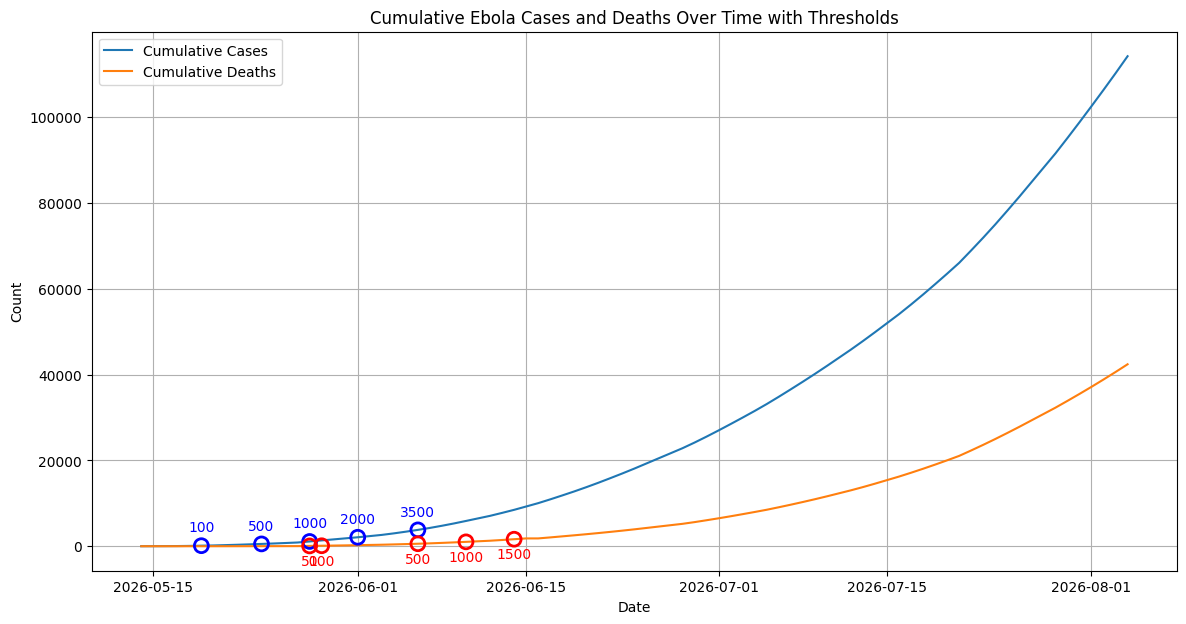

In [105]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Cumulative Cases', data=clean_national_daily_data, label='Cumulative Cases')
sns.lineplot(x='Date', y='Cumulative Deaths', data=clean_national_daily_data, label='Cumulative Deaths')

val = clean_national_daily_data.loc[clean_national_daily_data['Date'] == date_cases_100, 'Cumulative Cases'].values[0]
plt.scatter(date_cases_100, val, s=100, facecolors='none', edgecolors='blue', linewidths=2, zorder=5)
plt.annotate('100', (date_cases_100, val), textcoords="offset points", xytext=(0, 10), ha='center', color='blue')
val = clean_national_daily_data.loc[clean_national_daily_data['Date'] == date_cases_500, 'Cumulative Cases'].values[0]
plt.scatter(date_cases_500, val, s=100, facecolors='none', edgecolors='blue', linewidths=2, zorder=5)
plt.annotate('500', (date_cases_500, val), textcoords="offset points", xytext=(0, 10), ha='center', color='blue')
val = clean_national_daily_data.loc[clean_national_daily_data['Date'] == date_cases_1000, 'Cumulative Cases'].values[0]
plt.scatter(date_cases_1000, val, s=100, facecolors='none', edgecolors='blue', linewidths=2, zorder=5)
plt.annotate('1000', (date_cases_1000, val), textcoords="offset points", xytext=(0, 10), ha='center', color='blue')
val = clean_national_daily_data.loc[clean_national_daily_data['Date'] == date_cases_2000, 'Cumulative Cases'].values[0]
plt.scatter(date_cases_2000, val, s=100, facecolors='none', edgecolors='blue', linewidths=2, zorder=5)
plt.annotate('2000', (date_cases_2000, val), textcoords="offset points", xytext=(0, 10), ha='center', color='blue')
val = clean_national_daily_data.loc[clean_national_daily_data['Date'] == date_cases_3500, 'Cumulative Cases'].values[0]
plt.scatter(date_cases_3500, val, s=100, facecolors='none', edgecolors='blue', linewidths=2, zorder=5)
plt.annotate('3500', (date_cases_3500, val), textcoords="offset points", xytext=(0, 10), ha='center', color='blue')

# Mark death threshold crossings with circles
val = clean_national_daily_data.loc[clean_national_daily_data['Date'] == date_deaths_50, 'Cumulative Deaths'].values[0]
plt.scatter(date_deaths_50, val, s=100, facecolors='none', edgecolors='red', linewidths=2, zorder=5)
plt.annotate('50', (date_deaths_50, val), textcoords="offset points", xytext=(0, -14), ha='center', color='red')
val = clean_national_daily_data.loc[clean_national_daily_data['Date'] == date_deaths_100, 'Cumulative Deaths'].values[0]
plt.scatter(date_deaths_100, val, s=100, facecolors='none', edgecolors='red', linewidths=2, zorder=5)
plt.annotate('100', (date_deaths_100, val), textcoords="offset points", xytext=(0, -14), ha='center', color='red')
val = clean_national_daily_data.loc[clean_national_daily_data['Date'] == date_deaths_500, 'Cumulative Deaths'].values[0]
plt.scatter(date_deaths_500, val, s=100, facecolors='none', edgecolors='red', linewidths=2, zorder=5)
plt.annotate('500', (date_deaths_500, val), textcoords="offset points", xytext=(0, -14), ha='center', color='red')
val = clean_national_daily_data.loc[clean_national_daily_data['Date'] == date_deaths_1000, 'Cumulative Deaths'].values[0]
plt.scatter(date_deaths_1000, val, s=100, facecolors='none', edgecolors='red', linewidths=2, zorder=5)
plt.annotate('1000', (date_deaths_1000, val), textcoords="offset points", xytext=(0, -14), ha='center', color='red')
val = clean_national_daily_data.loc[clean_national_daily_data['Date'] == date_deaths_1500, 'Cumulative Deaths'].values[0]
plt.scatter(date_deaths_1500, val, s=100, facecolors='none', edgecolors='red', linewidths=2, zorder=5)
plt.annotate('1500', (date_deaths_1500, val), textcoords="offset points", xytext=(0, -14), ha='center', color='red')

plt.title('Cumulative Ebola Cases and Deaths Over Time with Thresholds')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()

**Q6(d): Average Daily Percentage Growth Rate**

In [107]:
# Calculate daily growth rates using the per-interval daily rates method
clean_national_daily_data['cases_daily_growth_rate_percent'] = clean_national_daily_data['Cumulative Cases'].pct_change() * 100
clean_national_daily_data['deaths_daily_growth_rate_percent'] = clean_national_daily_data['Cumulative Deaths'].pct_change() * 100

# Calculate daily growth rates using the log-linear method
# Taking the natural logarithm of the cumulative counts
clean_national_daily_data['log_cumulative_cases'] = np.log(clean_national_daily_data['Cumulative Cases'].replace(0, np.nan)) # Replace 0 with NaN to avoid log(0)
clean_national_daily_data['log_cumulative_deaths'] = np.log(clean_national_daily_data['Cumulative Deaths'].replace(0, np.nan)) # Replace 0 with NaN to avoid log(0)

clean_national_daily_data['cases_log_linear_growth_rate_percent'] = clean_national_daily_data['log_cumulative_cases'].diff() * 100
clean_national_daily_data['deaths_log_linear_growth_rate_percent'] = clean_national_daily_data['log_cumulative_deaths'].diff() * 100

clean_national_daily_data = clean_national_daily_data.drop(columns=['log_cumulative_cases', 'log_cumulative_deaths'])

# Calculate average daily growth rates, excluding NaN and inf values
avg_cases_per_interval = clean_national_daily_data['cases_daily_growth_rate_percent'].replace([np.inf, -np.inf], np.nan).mean()
avg_deaths_per_interval = clean_national_daily_data['deaths_daily_growth_rate_percent'].replace([np.inf, -np.inf], np.nan).mean()
avg_cases_log_linear = clean_national_daily_data['cases_log_linear_growth_rate_percent'].replace([np.inf, -np.inf], np.nan).mean()
avg_deaths_log_linear = clean_national_daily_data['deaths_log_linear_growth_rate_percent'].replace([np.inf, -np.inf], np.nan).mean()

print(f"Average Daily Case Growth Rate (Per-interval): {avg_cases_per_interval:.2f}%")
print(f"Average Daily Death Growth Rate (Per-interval): {avg_deaths_per_interval:.2f}%")
print(f"Average Daily Case Growth Rate (Log-linear): {avg_cases_log_linear:.2f}%")
print(f"Average Daily Death Growth Rate (Log-linear): {avg_deaths_log_linear:.2f}%")

display(clean_national_daily_data.head())

Average Daily Case Growth Rate (Per-interval): 12.87%
Average Daily Death Growth Rate (Per-interval): 16.47%
Average Daily Case Growth Rate (Log-linear): 11.21%
Average Daily Death Growth Rate (Log-linear): 13.28%


,Date,total_confirmed_cases,total_confirmed_deaths,Cumulative Cases,Cumulative Deaths,Cases Daily Growth Rate (%),Deaths Daily Growth Rate (%),Cases Log-Linear Growth Rate (%),Deaths Log-Linear Growth Rate (%),cases_daily_growth_rate_percent,deaths_daily_growth_rate_percent,cases_log_linear_growth_rate_percent,deaths_log_linear_growth_rate_percent
0,2026-05-14,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-05-15,13,0,13,0,inf,NaN,NaN,NaN,inf,NaN,NaN,NaN
2,2026-05-16,13,0,26,0,100.000000,NaN,69.314718,NaN,100.000000,NaN,69.314718,NaN
3,2026-05-17,13,0,39,0,50.000000,NaN,40.546511,NaN,50.000000,NaN,40.546511,NaN
4,2026-05-18,33,0,72,0,84.615385,NaN,61.310447,NaN,84.615385,NaN,61.310447,NaN


**Discussion of Growth Rate Results**

The **per-interval daily rates method** (`(current - previous) / previous * 100`) measures the percentage change from one day to the next. While it ia easier to understand, it can however be highly volatile, especially in the early stages of an outbreak or when daily numbers are small, leading to very large percentages. Case in point is when the previous day's count was zero.

The **log-linear method** (`(ln(current) - ln(previous)) * 100`) approximates the continuous growth rate. This is suitable for events that exhibit exponential growth or have the potential to, as it tends to be more stable and less sensitive to daily fluctuations.

**Which estimate to report and why?**

Given the nature of infectious disease outbreaks, which often follow an exponential growth pattern in their early phases, the **log-linear method** provides a more stable and consistent estimate of the average growth rate. It reflects the continuous compounding nature of such processes better than discrete per-interval changes.

Therefore, I would report the **log-linear average daily growth rate** for both cases and deaths.